# Main Code to carry out blocking statistics and diagnostics on model data (CESM+others) and observations

### Specific Code to:
#### 1. Setup the analysis to be done and data to be ingested
#### 2. Climatology plots
#### 3. Jet latitude index
#### 4. 1D Frequency plots
#### 5. 2d Frequency plots
#### 6. PDF of blocking strengths
#### 7. Composite of plots conditioned on blocking strength
#### 8. PDF of blocking/baroclinic events length

In [4]:
# IMPORT PACKAGES

import importlib
import blocking_utils as block_utils
import blocking_figs as block_figs

%load_ext autoreload
%autoreload 2

In [5]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [6]:
cluster = NCARCluster(project='P93300642',interface='mgt', job_extra_directives=[])
cluster
cluster.scale(jobs=8)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_blocking/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_blocking/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, 

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://10.18.205.16:39697,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B



# TOP LEVEL OPTIONS


In [7]:
ens_names = ['ERA5','MERRA','CESM1','CESM2','b.e30_beta04.BLTHIST.ne30_t232_wgx3.121']
ens_mem_num = [1,1,20,20,1]  # Ensemble members per ensemble set
#ens_ystart = ['1979']*len(ens_names)
#ens_yend     = ['2005']*len(ens_names)

ens_ystart = ['1979','1979','1979','1979','1979']
ens_yend     = ['2005','2005','2005','2005','2005']

block_season = 'MAM'
cam_var = 'Z500'
block_diag_hem = ['nhem']  
block_diag_set = ['1d']


# MAIN ROUTINES


In [8]:
importlib.reload(block_utils) # Required because I am constantly editing utility routines.

# Grab basic ens+run information and populate a dictionary)
block_meta = block_utils.ens_setup(ens_names,ens_mem_num,ens_ystart,ens_yend)

 
++ Large ensemble =  CESM1 :  20  out of  42  total (first/last) ++
b.e11.B20TRC5CNBDRD.f09_g16.001
b.e11.B20TRC5CNBDRD.f09_g16.020
 
++ Large ensemble =  CESM2 :  20  out of  50  total (first/last) ++
b.e21.BHISTcmip6.f09_g17.LE2-1001.001
b.e21.BHISTcmip6.f09_g17.LE2-1231.010


,Ensemble Type,Ensemble Size,Start Year,End Year,Run Name,Run File
ERA5,obs,1,1979,2005,[ERA5],[/glade/work/rneale/data/ERA5/VAR_TBD.day.mean...
MERRA,obs,1,1979,2005,[MERRA],[/glade/work/rneale/data/MERRA/VAR_TBD.day.mea...
CESM1,model,20,1979,2005,"[b.e11.B20TRC5CNBDRD.f09_g16.001, b.e11.B20TRC...",[/glade/campaign/cesm/collections/cesmLE/CESM-...
CESM2,model,20,1979,2005,"[b.e21.BHISTcmip6.f09_g17.LE2-1001.001, b.e21....",[/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/ts...
CESM3,model,1,1979,2005,[b.e30_beta04.BLTHIST.ne30_t232_wgx3.121],[/glade/derecho/scratch/rneale/archive/b.e30_b...


# Grab daily datasets needed for each 'ensemble'

In [9]:
ensemble_ds = block_utils.dataset_get(block_meta,cam_var,block_season,block_diag_hem)

-> dataset_get -> Requested season     :  MAM
-> dataset_get ->  Opening ensemble  ERA5  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening ensemble  MERRA  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening ensemble  CESM1  -  20  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening ensemble  CESM2  -  20  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening ensemble  CESM3  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Duration: 160.47569298744202



#  Calculate/Read/Write blocking frequency: 1D

In [10]:
ensemble_block_1d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '1D', file_opts = 'w')

['ERA5', 'MERRA', 'CESM1', 'CESM2', 'CESM3']
-> block_z500_freq ->   Calculating blocking statistics for  ERA5
-> block_file_read_write ->  Writing file for ensemble  ERA5  =  block_1D_ERA5_nens.1_1979-2005_MAM.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  1.6908212560386473 , 25.80515297906602
-> block_z500_freq ->   Calculating blocking statistics for  MERRA
-> block_file_read_write ->  Writing file for ensemble  MERRA  =  block_1D_MERRA_nens.1_1979-2005_MAM.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  MERRA  =  1.529790660225443 , 24.355877616747183
-> block_z500_freq ->   Calculating blocking statistics for  CESM1
-> block_file_read_write ->  Writing file for ensemble  CESM1  =  block_1D_CESM1_nens.20_1979-2005_MAM.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  CESM1  =  1.4492753623188406 , 32.1256


# Calculate/Read/Write blocking frequency: 2D


In [11]:
ensemble_block_2d = block_utils.block_z500_freq(block_meta,ensemble_ds,block_season,block_diag = '2D', file_opts = 'w')

['ERA5', 'MERRA', 'CESM1', 'CESM2', 'CESM3']
-> block_z500_freq ->   Calculating blocking statistics for  ERA5
-> block_file_read_write ->  Writing file for ensemble  ERA5  =  block_2D_ERA5_nens.1_1979-2005_MAM.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  0.0 , 47.58454106280193
-> block_z500_freq ->   Calculating blocking statistics for  MERRA
-> block_file_read_write ->  Writing file for ensemble  MERRA  =  block_2D_MERRA_nens.1_1979-2005_MAM.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  MERRA  =  0.0 , 80.07246376811594
-> block_z500_freq ->   Calculating blocking statistics for  CESM1
-> block_file_read_write ->  Writing file for ensemble  CESM1  =  block_2D_CESM1_nens.20_1979-2005_MAM.nc
-> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  CESM1  =  0.0 , 54.468599033816425
-> block_z500_freq ->   Calculati


# Plot 1D blocking: Shade = 1,2 +/- std (or min to max range)


-> block_plot_1d ->  Plotting for ensemble ERA5
-> block_plot_1d ->  Plotting for ensemble MERRA
-> block_plot_1d ->  Plotting for ensemble CESM1
-> block_plot_1d ->  Plotting for ensemble CESM2
-> block_plot_1d ->  Plotting for ensemble CESM3
-> block_plot_1d ->  Duration: 1.8799874782562256



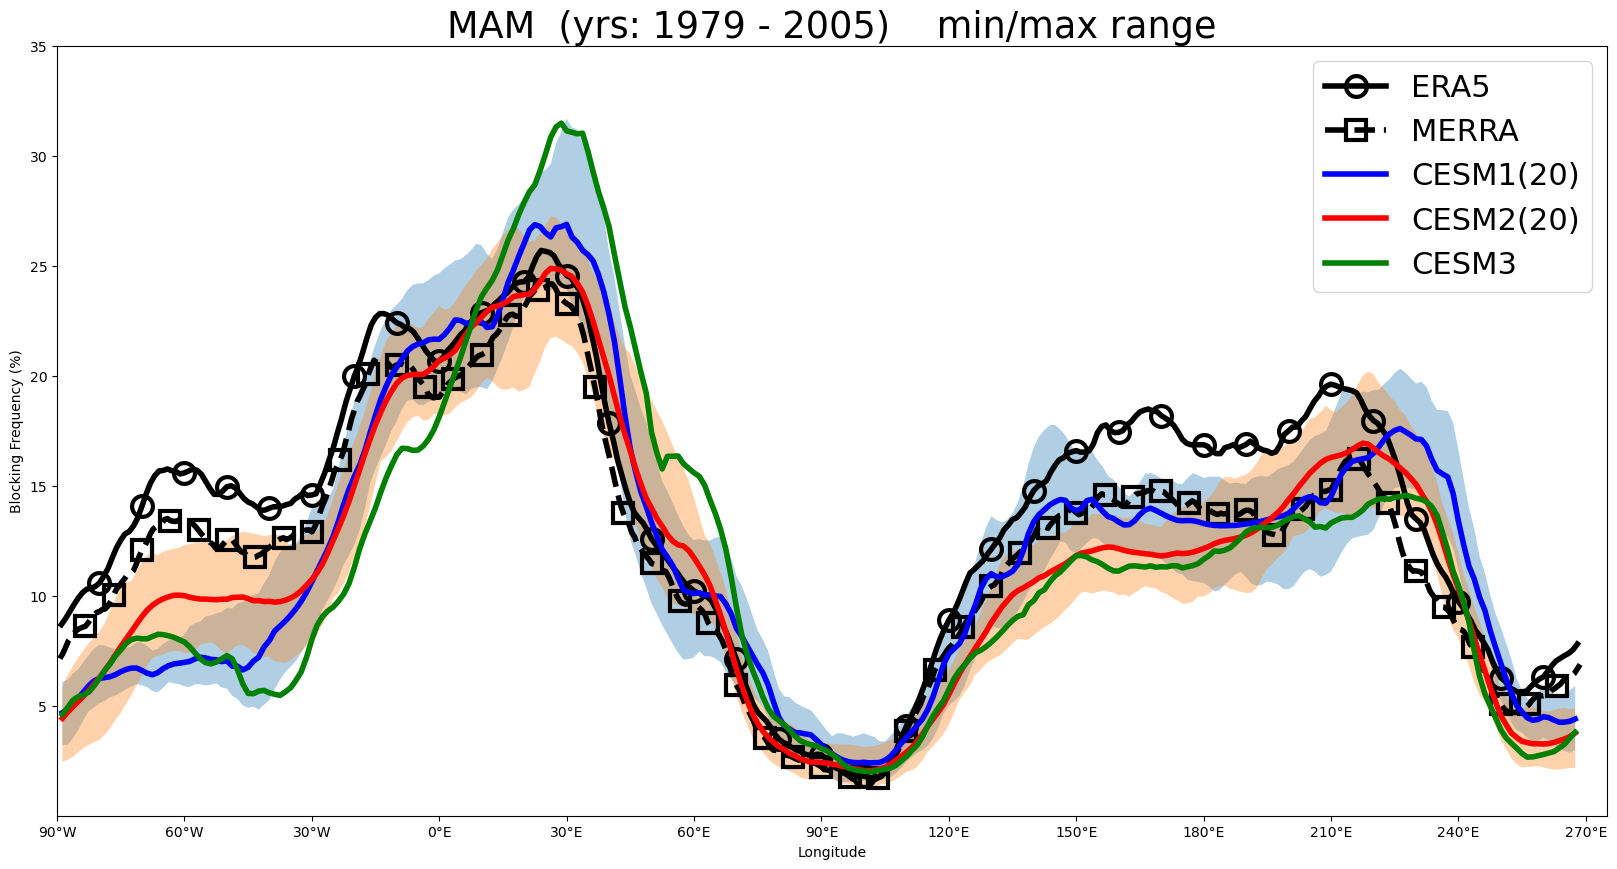

In [12]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True)


# Plot 2D blocking: Ensemble ave, 1 ensemble member, or all ensemble members 


-> block_plot_2d -> Plotting for ensemble ERA5
-> block_plot_2d -> Plotting for ensemble MERRA
-> block_plot_2d -> Plotting for ensemble CESM1
-> block_plot_2d -> Plotting for ensemble CESM2
-> block_plot_2d -> Plotting for ensemble CESM3


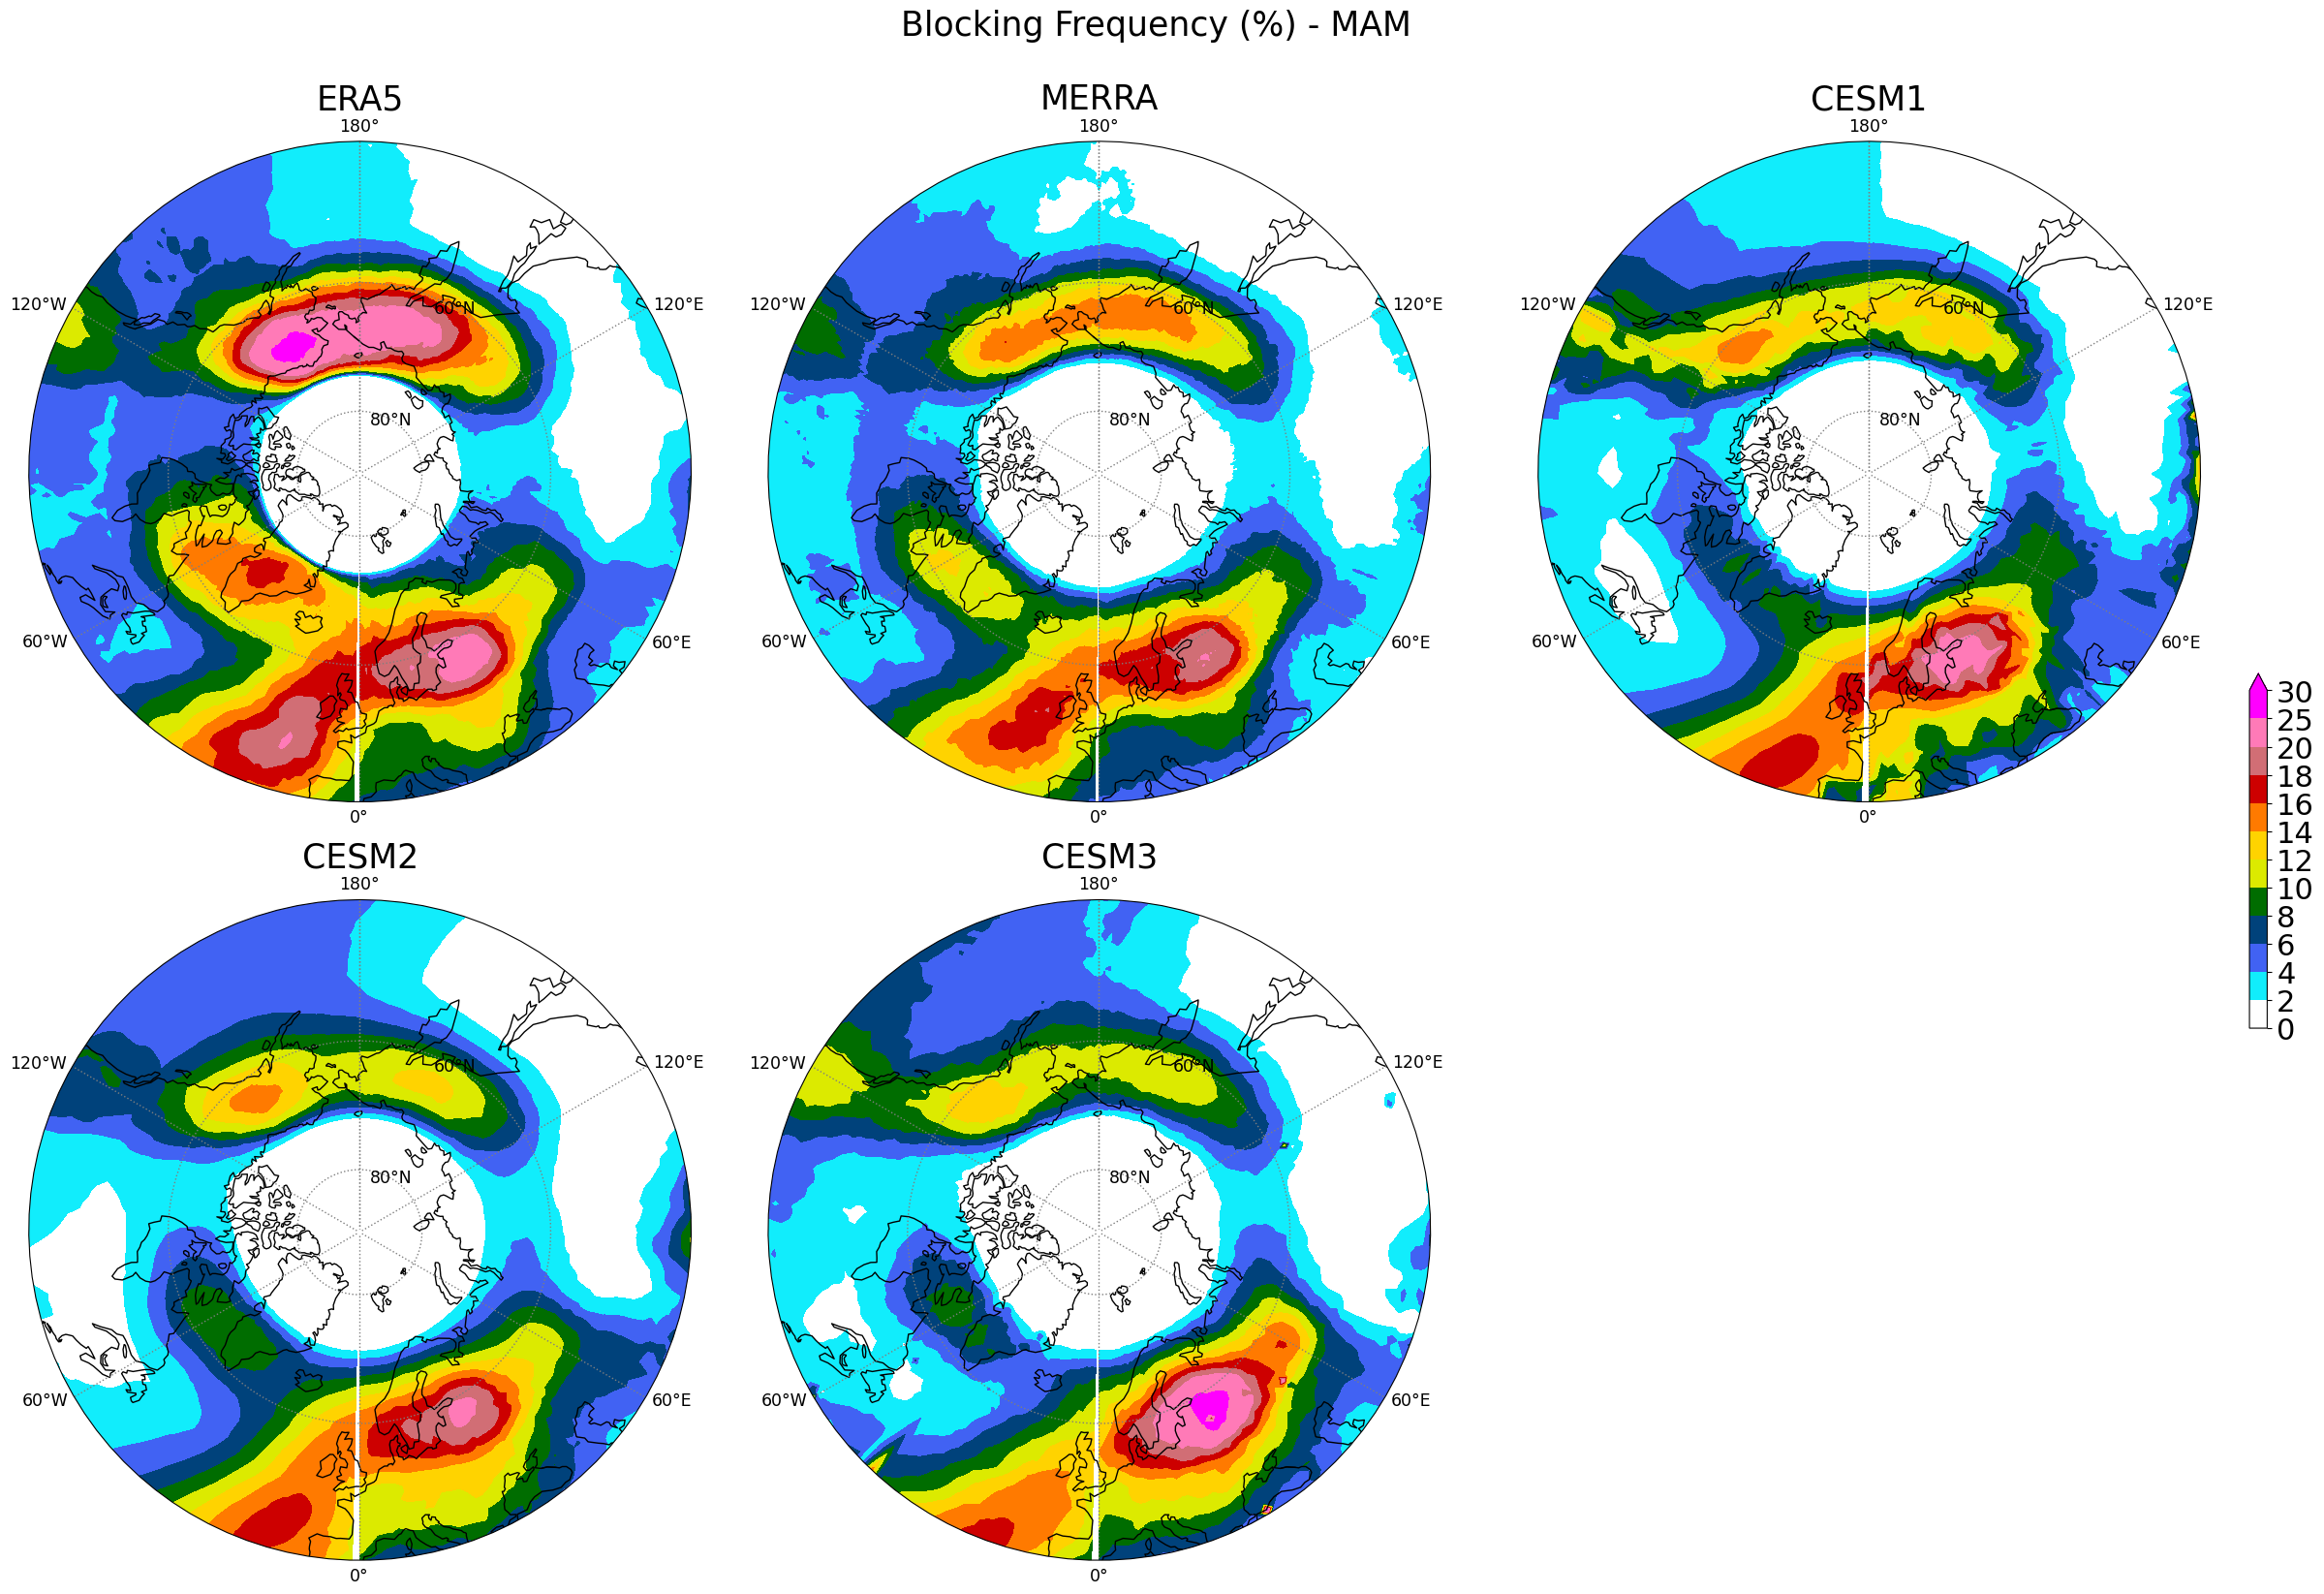

In [13]:
block_figs.block_plot_2d(block_meta,ensemble_block_2d,block_season,fig_out=True,ens_plot='av')


# Plot 1d regional blocking PDFs (European, Pacific and Greenland)


In [ ]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,ens_plot='1',fig_out=True)

TypeError: block_plot_1d() got an unexpected keyword argument 'ens_plot'

In [ ]:
#bstats = atmos_block.stats
#bclimo = atmos_block.climo
#bjet_lat = atmos_block.get_lat
#bfreq_1d = atmos_block.bfreq_1d
#bfreq_2d = atmos_block.bfreq_2d
#bpdf_1d = atmos_block.bfreq_2d
#bcomp_lag = atmos_block.bfreq_lag
#bday_len = atmos_block.bday_len